# 배송 시간에 영향을 주는 요인

In [2]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike

## 시각화 모듈
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns
import plotly.graph_objects as go

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 머신러닝 모듈
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd
from src.utils import calculate_distance, detect_and_remove_outliers
from src.config import state_neighbors, state_region_map

DATA_DIR = Path('../data/processed')

In [3]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'Freesentation'
    plt.rcParams['font.weight'] = 600  # SemiBold에 해당
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['Freesentation']


In [4]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data: pd.DataFrame = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,order_id,order_qty,total_price,product_id,product_qty,category,review_score,price,freight_value,purchase_time,...,city_cust,state_cust,customer_id,customer_unique_id,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,00e7ee1b050b8499577073aeb2a297a1,1,146.87,a9516a079e37a9c9c36b9b78b10169e8,1,가구·인테리어,4.0,124.99,21.88,2017-05-16 15:05:35,...,franca,SP,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,29150127e6685892b6eab3eec79f59c7,1,335.48,4aa6014eceb682077f9dc4bffebc05b0,1,생활용품,5.0,289.00,46.48,2018-01-12 20:48:24,...,sao bernardo do campo,SP,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,b2059ed67ce144a36e2aa97d2c9e9ad2,1,157.73,bd07b66896d6f1494f5b86251848ced7,1,가구·인테리어,5.0,139.94,17.79,2018-05-19 16:07:45,...,sao paulo,SP,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,951670f92359f4fe4a63112aa7306eba,1,173.30,a5647c44af977b148e0a3a4751a09e2e,1,가구·인테리어,5.0,149.94,23.36,2018-03-13 16:06:38,...,mogi das cruzes,SP,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,6b7d50bd145f6fc7f33cebabd7e49d0f,1,252.25,9391a573abe00141c56e38d84d7d5b3b,1,가구·인테리어,5.0,230.00,22.25,2018-07-29 09:51:30,...,campinas,SP,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100696,6760e20addcf0121e9d58f2f1ff14298,1,88.78,ccb4503d9d43d245d3b295d0544f988b,1,도서·미디어,4.0,74.90,13.88,2018-04-07 15:48:17,...,sao paulo,SP,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
100697,9ec0c8947d973db4f4e8dcf1fbfa8f1b,1,129.06,9ede6b0570a75a4b9de4f383329f99ee,1,스포츠·레저,5.0,114.90,14.16,2018-04-04 08:20:22,...,taboao da serra,SP,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
100698,fed4434add09a6f332ea398efd656a5c,1,56.04,7a5d2e1e131a860ae7d18f6fffa9d689,1,건강·뷰티,1.0,37.00,19.04,2018-04-08 20:11:50,...,fortaleza,CE,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
100699,e31ec91cea1ecf97797787471f98a8c2,1,711.07,f819f0c84a64f02d3a5606ca95edd272,1,패션·의류,5.0,689.00,22.07,2017-11-03 21:08:33,...,canoas,RS,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


In [5]:
ids = processed_data[(processed_data['weight_g'] == 0) & (processed_data['length'] == 0)].index
processed_data.drop(index=ids, inplace=True)

In [6]:
grouped = processed_data.drop_duplicates('order_id').groupby('customer_unique_id', as_index=False).agg(cnt_order=('order_id', 'nunique'))
repurchase_cond = grouped['cnt_order'] > 1
grouped[repurchase_cond].size / grouped.size * 100

2.9701234080796124

## 파생변수 추가

In [7]:
# 배송 시간 관련
processed_data['approved_hours'] = ((processed_data['approved_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['carrier_delivered_hours'] = ((processed_data['carrier_delivered_time'] - processed_data['approved_time']).dt.total_seconds() / 3600).round()
processed_data['last_mile_hours'] = ((processed_data['delivered_time'] - processed_data['carrier_delivered_time']).dt.total_seconds() / 3600).round()
processed_data['delivered_hours'] = ((processed_data['delivered_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['delayed_days'] = (processed_data['delivered_time'] - processed_data['estimated_delivery_time']).dt.days

In [8]:
# 거리
processed_data['distance'] = calculate_distance(processed_data, 'latitude_cust', 'longitude_cust', 'latitude_sell', 'longitude_sell')

In [9]:
# 시계열 관련
processed_data['weekday_purchase'] = processed_data['purchase_time'].dt.dayofweek
processed_data['month_purchase'] = processed_data['purchase_time'].dt.month

In [10]:
review_data = processed_data[processed_data['review_score'] != '리뷰없음']
review_data = review_data.copy()
review_data['review_score'] = review_data['review_score'].astype(float).astype(int)
review_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99808 entries, 0 to 100700
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 99808 non-null  object        
 1   order_qty                99808 non-null  int64         
 2   total_price              99808 non-null  float64       
 3   product_id               99808 non-null  object        
 4   product_qty              99808 non-null  int64         
 5   category                 99808 non-null  object        
 6   review_score             99808 non-null  int64         
 7   price                    99808 non-null  float64       
 8   freight_value            99808 non-null  float64       
 9   purchase_time            99808 non-null  datetime64[ns]
 10  approved_time            99808 non-null  datetime64[ns]
 11  carrier_delivered_time   99808 non-null  datetime64[ns]
 12  delivered_time           99808 non-n

In [11]:
train_test_split_date = '2018-05-01'
train_cond = review_data['purchase_time'] < train_test_split_date

train_data = review_data[train_cond]
test_data = review_data[~train_cond]

## 분석

In [12]:
order_group = train_data.groupby('order_id').agg(
    승인시간 = ('approved_hours', 'max'),
    인수시간 = ('carrier_delivered_hours', 'max'),
    운송시간 = ('last_mile_hours', 'max'),
    총배송시간 = ('delivered_hours', 'max'),
    지연일 = ('delayed_days', 'max'),
    거리 = ('distance', 'max'),
    주문요일 = ('weekday_purchase', 'max'),
    주문월 = ('month_purchase', 'max'),
    무게 = ('weight_g', 'sum'),
    판매자주 = ('state_sell', 'max'),
    구매자주 = ('state_cust', 'max'),
    # 평점 = ('review_score', 'max')
)

order_group

,승인시간,인수시간,운송시간,총배송시간,지연일,거리,주문요일,주문월,무게,판매자주,구매자주
order_id,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1.0,153.0,29.0,183.0,-9,302.215359,2,9,650.0,RJ,RJ
00018f77f2f0320c557190d7a144bdd3,0.0,195.0,193.0,389.0,-3,587.836868,2,4,30000.0,SP,SP
000229ec398224ef6ca0657da4fc703e,0.0,46.0,145.0,191.0,-14,307.364354,6,1,3050.0,MG,MG
00042b26cf59d7ce69dfabb4e55b4fd9,0.0,284.0,319.0,603.0,-16,646.682058,5,2,3750.0,PR,SP
00048cc3ae777c65dbb7d2a0634bc1ea,30.0,7.0,123.0,160.0,-15,161.089367,0,5,450.0,SP,MG
...,...,...,...,...,...,...,...,...,...,...,...
fffb2ef8874127f75b52b643880fd7e0,86.0,10.0,314.0,409.0,-11,874.558274,4,3,200.0,SC,RJ
fffb9224b6fc7c43ebb0904318b10b5f,10.0,329.0,168.0,507.0,-10,1725.602007,4,10,350.0,RJ,PE
fffc94f6ce00a00581880bf54a75a037,38.0,8.0,371.0,417.0,-8,2756.382096,0,4,10150.0,SC,MA


In [13]:
delivery_data = order_group.copy()

delivery_data['승인비율'] = delivery_data['승인시간'] / delivery_data['총배송시간'] * 100
delivery_data['인수비율'] = delivery_data['인수시간'] / delivery_data['총배송시간'] * 100
delivery_data['운송비율'] = delivery_data['운송시간'] / delivery_data['총배송시간'] * 100
delivery_data['승인지연'] =  round(delivery_data['지연일'] * delivery_data['승인시간'] / delivery_data['총배송시간'])
delivery_data['인수지연'] =  round(delivery_data['지연일'] * delivery_data['인수시간'] / delivery_data['총배송시간'])
delivery_data['운송지연'] =  round(delivery_data['지연일'] * delivery_data['운송시간'] / delivery_data['총배송시간'])

In [14]:
delivery_data.describe()

,승인시간,인수시간,운송시간,총배송시간,지연일,거리,주문요일,주문월,무게,승인비율,인수비율,운송비율,승인지연,인수지연,운송지연
count,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000,69265.000000
mean,9.769927,71.711658,245.831675,327.439269,-11.506201,613.783062,2.772786,5.867595,2285.491071,3.697752,25.310853,70.928394,-0.453086,-3.028109,-8.005472
std,19.965673,83.728520,223.827969,241.529655,10.165478,593.333282,1.968121,3.692818,4236.052162,8.034759,20.201043,21.062218,1.224921,3.555203,8.518274
min,0.000000,0.000000,0.000000,13.000000,-147.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,-29.000000,-62.000000,-90.000000
25%,0.000000,24.000000,118.000000,177.000000,-17.000000,217.427119,1.000000,3.000000,300.000000,0.000000,9.404389,58.704453,0.000000,-4.000000,-12.000000
50%,0.000000,48.000000,190.000000,271.000000,-13.000000,448.759733,3.000000,5.000000,750.000000,0.000000,19.540230,76.282051,0.000000,-2.000000,-8.000000
75%,14.000000,92.000000,314.000000,408.000000,-8.000000,810.360530,4.000000,9.000000,1950.000000,3.910615,36.184211,87.641357,0.000000,-1.000000,-4.000000
max,741.000000,3018.000000,4925.000000,5000.000000,188.000000,3386.918132,6.000000,12.000000,154200.000000,84.070796,100.000000,100.000000,10.000000,100.000000,185.000000


In [15]:
def plot_one_feature(data: pd.DataFrame, feature, color, axes):
    sns.boxplot(data, y=feature, color=color, ax=axes[0])
    axes[0].set_title('Box Plot')
    axes[0].grid(True, alpha=0.3)
    stats.probplot(data[feature], dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    axes[1].grid(True, alpha=0.3)
    sns.histplot(data, x=feature, color=color, ax=axes[2])
    axes[2].set_title('히스토그램')
    axes[2].grid(True, alpha=0.3)

def plot_features(data: pd.DataFrame, features, colors):
    n = len(features)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    
    for i in range(n):
        feature, color = features[i], colors[i]
        ax = axes if n == 1 else axes[i]
        plot_one_feature(data, feature, color, ax)

    plt.tight_layout()
    plt.show()

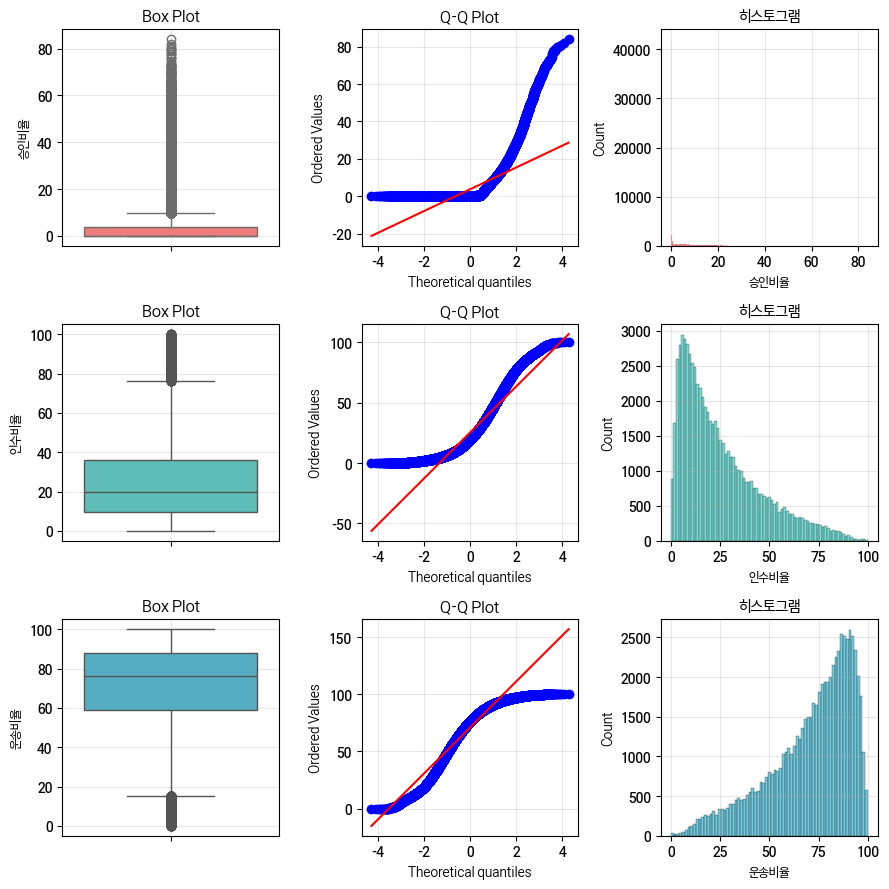

In [16]:
features = ['승인비율', '인수비율', '운송비율']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', "#96CEB4", '#FECA57']
plot_features(delivery_data, features, colors[:3])

In [22]:
ratio_df = delivery_data[['승인비율', '인수비율', '운송비율']]

ratio_trimmed = ratio_df.apply(lambda x: x[(x >= x.quantile(0.25)) & (x <= x.quantile(0.75))])

# 절제평균 계산 → 실제 전체 평균 비중
ratio_mean = ratio_trimmed.mean()
ratio_share = (ratio_mean / ratio_mean.sum() * 100).round(1)

print(ratio_share)
print("합계:", ratio_share.sum().round(2))

승인비율     0.3
인수비율    21.4
운송비율    78.4
dtype: float64
합계: 100.1


In [67]:
def categorize_state_map(row: pd.Series):
    adj_cond = row['판매자주'] in state_neighbors[row['구매자주']]
    region_cond = state_region_map[row['구매자주']] == state_region_map[row['판매자주']]
    if row['구매자주'] == row['판매자주']:
        return '주 내부'
    elif adj_cond | region_cond:
        return '인근지역'
    else:
        return '광역권외'

delivery_data['거리분류'] = delivery_data.apply(categorize_state_map, axis=1).astype('category')

In [68]:
# 실행 필요
distance_group = delivery_data.groupby('거리분류', observed=True)['거리'].agg([
    'count', 'mean', 'median', 'std'
])
print(distance_group)

      count         mean       median         std
거리분류                                             
광역권외  21169  1266.279260  1039.941444  637.586371
인근지역  24271   492.409982   469.123088  194.090663
주 내부  23825   157.672004    99.780242  150.248803


In [69]:
delivery_data.columns

Index(['승인시간', '인수시간', '운송시간', '총배송시간', '지연일', '거리', '주문요일', '주문월', '무게',
       '판매자주', '구매자주', '승인비율', '인수비율', '운송비율', '승인지연', '인수지연', '운송지연', '거리분류'],
      dtype='object')

## 🚚 Olist 운송시간 예측 머신러닝 분석

전자상거래 플랫폼 Olist에서 판매자로부터 구매자까지의 실제 운송 소요시간을 정확히 예측하여, 배송 지연 리스크를 사전 식별하고 물류 효율성을 개선할 수 있는 예측 모델을 구축

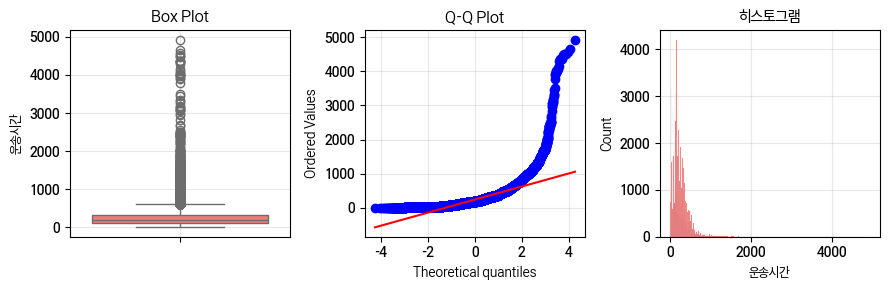

In [70]:
target = '운송시간'

plot_features(delivery_data, [target], colors[:1])

### 타겟 이상치 제거 및 정규성 검증


[IQR 방식 이상치 제거 결과]
음수 제거: 0건
이상치 제거: 3,863건 (5.58%)
최종 데이터: 65,402건
범위: 0.0 ~ 608.0 시간


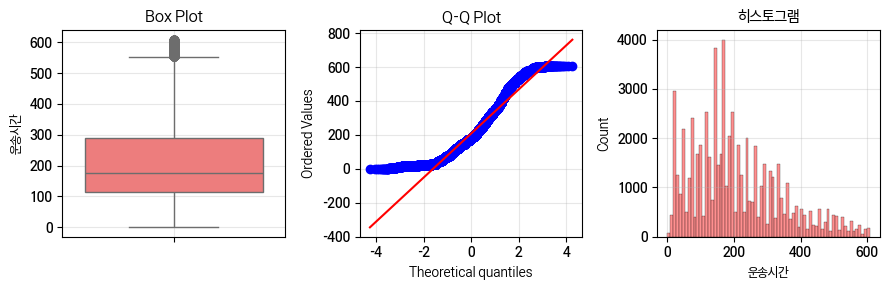

In [71]:
removed_data, _, _ = detect_and_remove_outliers(delivery_data, target)

plot_features(removed_data, [target], colors[:1])

In [72]:
from numpy.typing import ArrayLike
import pandas as pd
from scipy import stats
from scipy.stats import shapiro

def check_normality_simple(data: ArrayLike, name: str = "데이터") -> bool:
    """
    데이터의 정규성을 검정하는 함수
    
    Parameters
    ----------
    data : array-like
        정규성을 검정할 데이터 (NaN은 자동 제거)
    name : str, default="데이터"
        출력 시 표시될 데이터 이름
    
    Returns
    -------
    bool
        정규분포 가정 충족 여부
        - True: 정규분포 가정 가능 (모수 검정)
        - False: 정규분포 가정 위반 (비모수 검정)
    
    검정 기준
    ---------
    - n < 30: Shapiro-Wilk 검정 (p > 0.05)
    - 30 ≤ n < 100: 왜도/첨도 우선, 필요시 Shapiro-Wilk
    - n ≥ 100: 왜도 기준 (|왜도| < 2, 중심극한정리)
    """
    # Pandas Series로 캐스팅 (리스트/넘파이 등 허용), 숫자만 대상으로 가정
    data = pd.Series(data)
    
    # NaN 체크
    if pd.isna(data).any():
        print(f"⚠️ 경고: {name}에 NaN 값이 {pd.isna(data).sum()}개 포함됨")
        data = data.dropna()
        print(f"   → NaN 제거 후 n={len(data)}")
    
    n = len(data)
    
    if n == 0:
        print(f"[{name} 정규성 검정] 유효한 데이터가 없습니다.")
        return False
    
    print(f"\n[{name} 정규성 검정] n={n}")
    print("-"*40)
    
    # 왜도와 첨도
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)
    print(f"왜도(Skewness): {skew:.3f}")
    print(f"첨도(Kurtosis): {kurt:.3f}")
    
    # 표본 크기에 따른 판단
    if n < 30:
        _, p = shapiro(data)
        print(f"Shapiro-Wilk p-value: {p:.4f}")
        is_normal = p > 0.05
        reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    elif n < 100:
        if abs(skew) < 1 and abs(kurt) < 2:
            is_normal = True
            reason = "|왜도|<1, |첨도|<2"
        else:
            _, p = shapiro(data)
            print(f"추가 Shapiro-Wilk p-value: {p:.4f}")
            is_normal = p > 0.05
            reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    else:
        is_normal = abs(skew) < 2
        reason = f"|왜도|{'<' if is_normal else '≥'}2 (중심극한정리)"
    
    print(f"결과: {'✅ 정규분포 가정 충족' if is_normal else '❌ 정규분포 가정 위반'} ({reason})")
    return is_normal

In [73]:
check_normality_simple(removed_data[target], target)


[운송시간 정규성 검정] n=65402
----------------------------------------
왜도(Skewness): 0.783
첨도(Kurtosis): 0.065
결과: ✅ 정규분포 가정 충족 (|왜도|<2 (중심극한정리))


np.True_

### 연속형 변수 분석

In [89]:
removed_data[['거리', '운송시간']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 65402 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe18544ffabc95dfada21779c9644f
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   거리      65402 non-null  float64
 1   운송시간    65402 non-null  float64
dtypes: float64(2)
memory usage: 3.5+ MB


In [74]:
import plotly.graph_objects as go
import numpy as np

# 샘플링 (10,000개 또는 데이터의 10%)
sample_size = min(20000, int(len(removed_data) * 0.3))
sampled_data = removed_data.sample(n=sample_size, random_state=42)

fig = go.Figure()

fig.add_trace(go.Scattergl(  # Scattergl로 변경 (WebGL 가속)
    x=sampled_data['거리'], 
    y=sampled_data[target], 
    mode="markers",
    marker=dict(
        size=4,  # 크기 축소
        color=sampled_data[target], 
        colorscale="Viridis",
        opacity=0.6,  # 투명도 추가
        line=dict(width=0)  # 테두리 제거
    ),
    name="data"
))

fig.update_layout(
    title=f'거리 x 운송시간 산점도 (샘플: {sample_size:,}개)',
    xaxis_title="거리 (km)",
    yaxis_title="운송시간 (hours)",
    template="plotly_dark",
    width=700, height=500
)

fig.show()

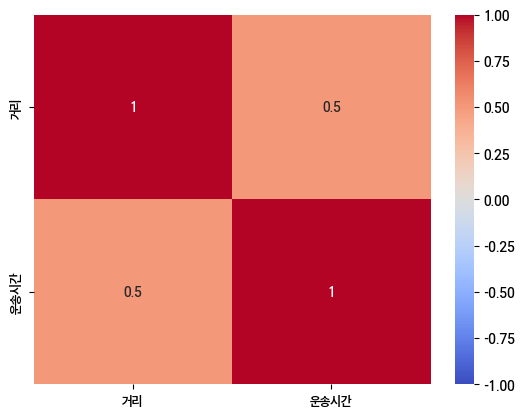

In [75]:
corr = removed_data[['거리', '운송시간']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

#### 무게 포함할까? -> X

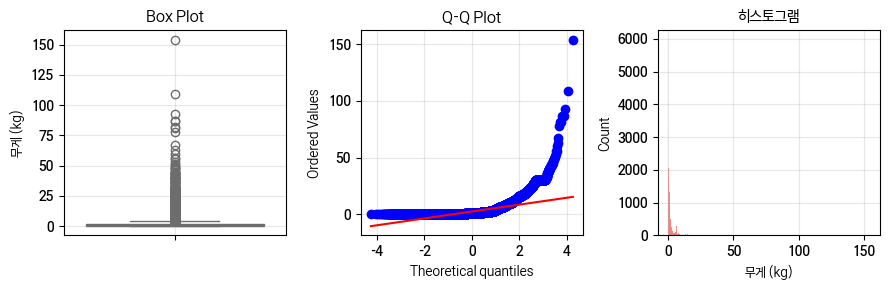

In [76]:
removed_data['무게 (kg)'] = removed_data['무게'] / 1000
plot_features(removed_data, ['무게 (kg)'], colors[:1])

In [79]:
# 평균, 중앙값, 표준편차까지
print(removed_data.groupby(pd.qcut(removed_data['무게'], q=4, duplicates='drop'), observed=True)['운송시간'].agg(['min', 'max', 'mean', 'median', 'std', 'count']))

                    min    max        mean  median         std  count
무게                                                                   
(1.999, 300.0]      0.0  607.0  198.955578   170.0  135.803747  17739
(300.0, 728.0]      0.0  608.0  207.984027   178.0  133.932103  14963
(728.0, 1938.0]     0.0  608.0  211.894656   186.0  130.818220  16356
(1938.0, 154200.0]  0.0  608.0  213.848201   187.0  134.453062  16344


In [86]:
# 극단적으로 무거운 화물 (상위 1%)만 분석
heavy_threshold = removed_data['무게'].quantile(0.99)
df_heavy = removed_data[removed_data['무게'] > heavy_threshold]

print(f"극단 무게 (>{heavy_threshold}g) 평균 운송시간: {df_heavy['운송시간'].mean():.1f}h")
print(f"일반 무게 평균 운송시간: {removed_data[removed_data['무게'] <= heavy_threshold]['운송시간'].mean():.1f}h")

# T-test
from scipy.stats import ttest_ind
stat, p = ttest_ind(df_heavy['운송시간'], 
                     removed_data[removed_data['무게'] <= heavy_threshold]['운송시간'])
print(f"T-statistic: {stat:.2f}, p-value: {p:.6f}")

극단 무게 (>20450.0g) 평균 운송시간: 207.0h
일반 무게 평균 운송시간: 208.0h
T-statistic: -0.20, p-value: 0.844126


#### 비선형관계

In [90]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 데이터 준비
X = removed_data[['거리']].values
y = removed_data['운송시간'].values

# 1차(선형), 2차, 3차 모델 비교
results = {}
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    results[f'{degree}차'] = r2_score(y, y_pred)

# 결과 출력
for degree, r2 in results.items():
    print(f"{degree}: R² = {r2:.4f}")

# R² 개선도 확인
r2_improvement = results['2차'] - results['1차']
print(f"\n2차 모델 개선도: {r2_improvement:.4f}")
print(f"비선형 관계: {'존재' if r2_improvement > 0.01 else '미약'}")

1차: R² = 0.2534
2차: R² = 0.3066
3차: R² = 0.3172

2차 모델 개선도: 0.0531
비선형 관계: 존재


In [ ]:
# 2차 다항 회귀 필요함

### 범주형 변수 분석

In [99]:
removed_data[['운송시간', '주문요일', '주문월']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 65402 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe18544ffabc95dfada21779c9644f
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   운송시간    65402 non-null  float64
 1   주문요일    65402 non-null  int32  
 2   주문월     65402 non-null  int32  
dtypes: float64(1), int32(2)
memory usage: 3.5+ MB


📊 주문요일별 운송량 및 평균 운송시간 분석
        주문량  평균_운송시간  중앙값_운송시간    표준편차
주문요일                                  
월     10559   206.44     174.0  134.51
화     10414   208.09     173.0  132.56
수     10050   209.00     173.0  132.07
목      9804   211.20     181.0  133.40
금      9465   207.70     185.0  134.05
토      7176   209.03     187.0  136.65
일      7934   203.98     176.0  135.24

📊 주문월별 운송량 및 평균 운송시간 분석
     주문량  평균_운송시간  중앙값_운송시간    표준편차
월                                  
1   7286   212.14     184.0  136.51
2   7303   238.79     216.0  144.68
3   8454   219.80     188.0  145.11
4   8207   194.72     168.0  131.48
5   3413   185.26     168.0  110.24
6   3018   197.14     175.0  115.65
7   3690   186.28     168.0  116.66
8   4050   180.91     166.0  119.03
9   3985   192.56     170.0  119.98
10  4316   187.55     168.0  116.71
11  6680   220.01     193.0  136.54
12  5000   232.54     197.0  149.27



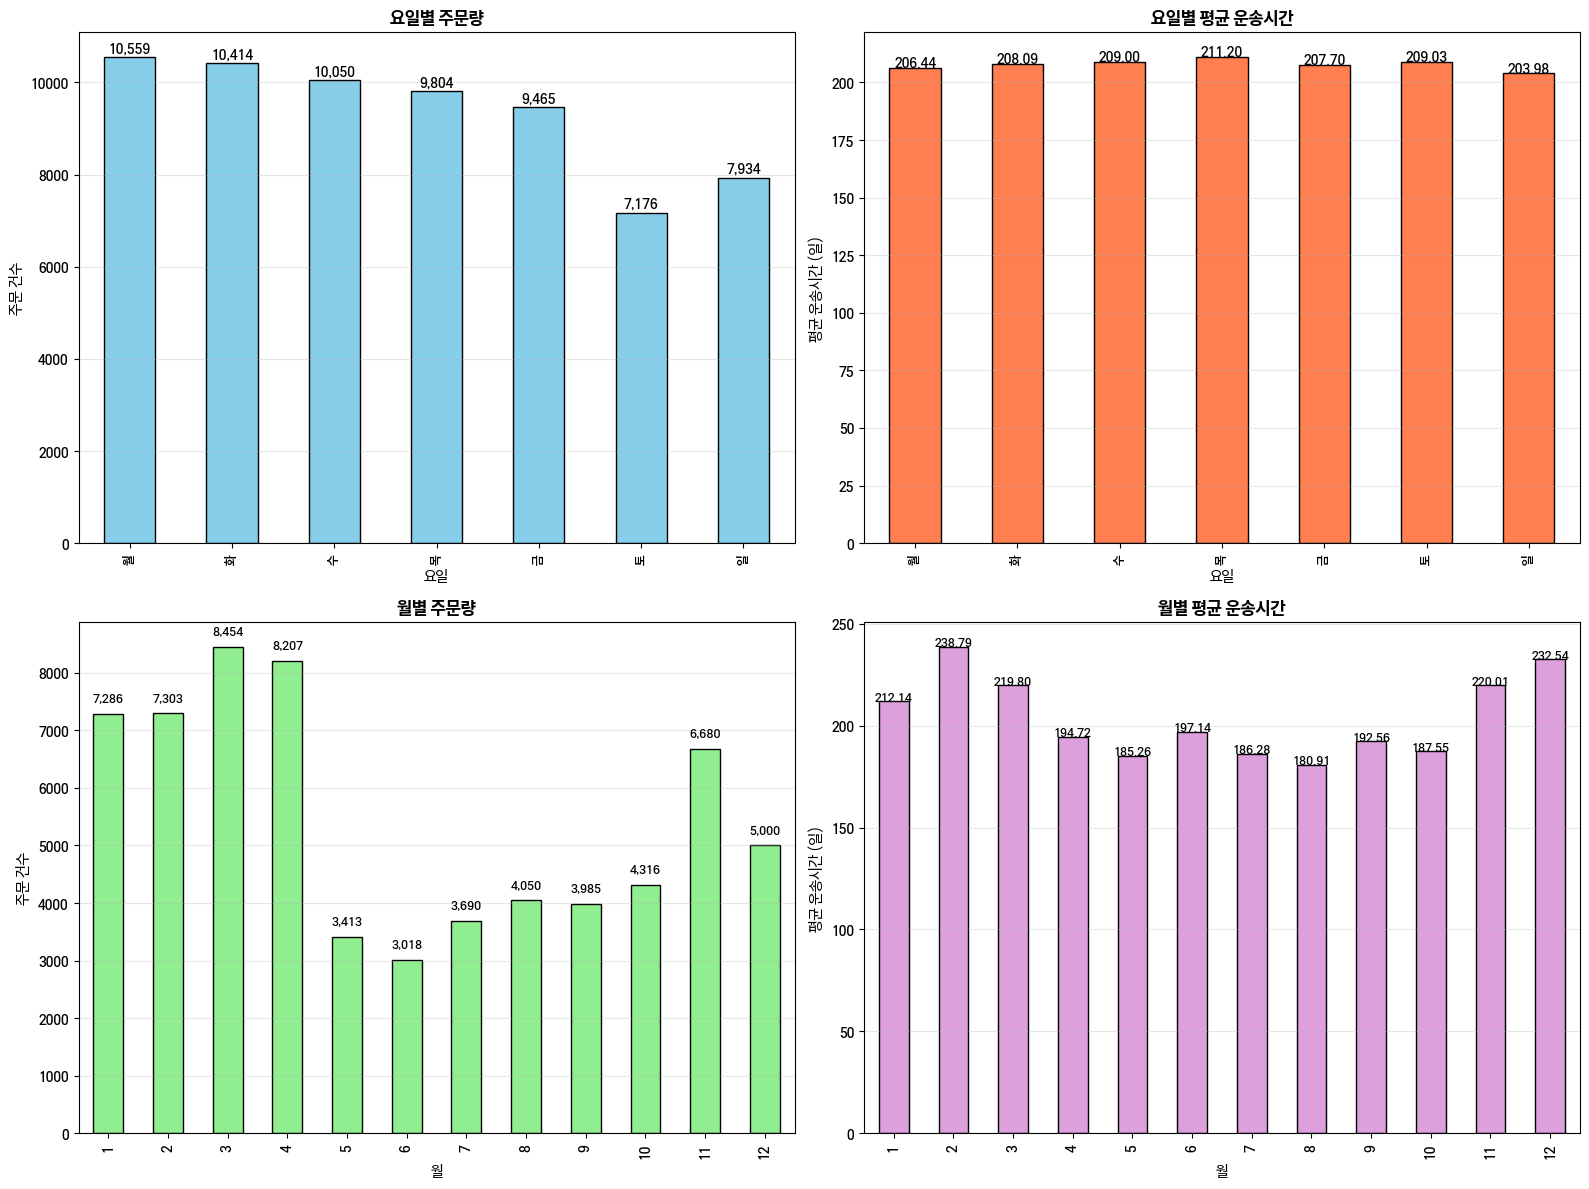

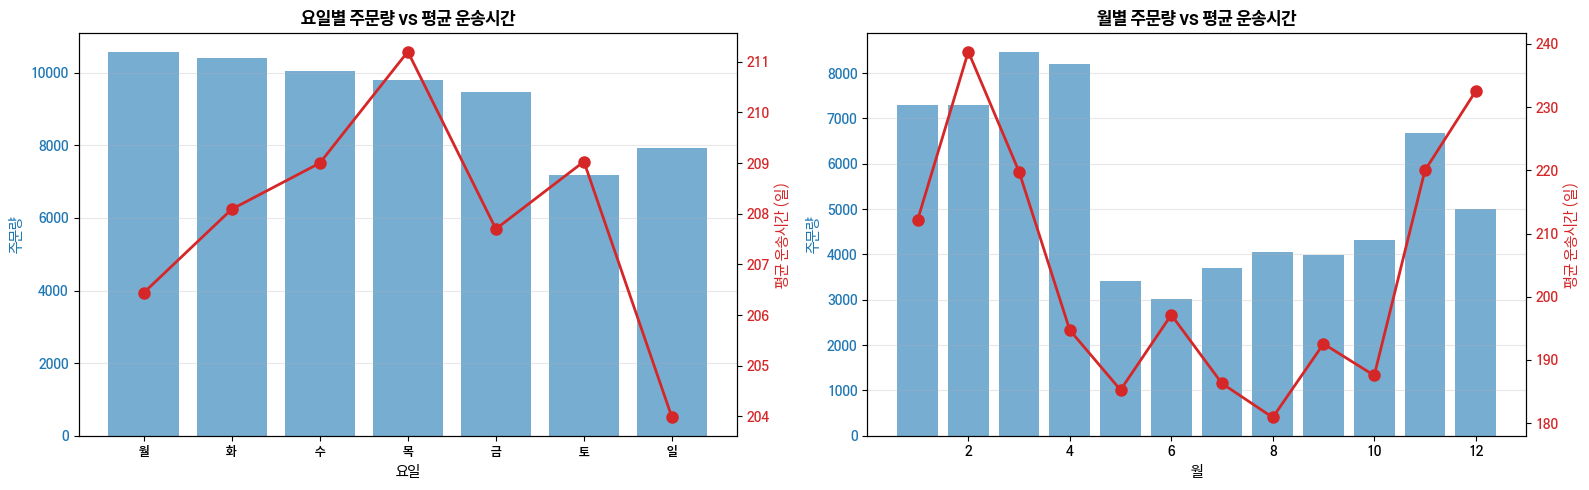


📈 통계적 유의성 검정 (일원배치 분산분석)

[요일별 운송시간 차이 검정]
F-통계량: 2.5360
p-value: 0.018652
유의수준 0.05 기준: 유의미한 차이 있음 ✅

[월별 운송시간 차이 검정]
F-통계량: 120.1101
p-value: 0.000000
유의수준 0.05 기준: 유의미한 차이 있음 ✅

[효과 크기 - Eta-squared]
요일: η² = 0.000233 (작음)
월: η² = 0.019805 (중간)

✅ 분석 완료!


In [100]:
# 1. 요일별 분석
print("=" * 60)
print("📊 주문요일별 운송량 및 평균 운송시간 분석")
print("=" * 60)

weekday_analysis = removed_data.groupby('주문요일').agg({
    '운송시간': ['count', 'mean', 'median', 'std']
}).round(2)

weekday_analysis.columns = ['주문량', '평균_운송시간', '중앙값_운송시간', '표준편차']
weekday_analysis = weekday_analysis.sort_index()

# 요일명 매핑
weekday_names = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
weekday_analysis.index = weekday_analysis.index.map(weekday_names)

print(weekday_analysis)
print()

# 2. 월별 분석
print("=" * 60)
print("📊 주문월별 운송량 및 평균 운송시간 분석")
print("=" * 60)

month_analysis = removed_data.groupby('주문월').agg({
    '운송시간': ['count', 'mean', 'median', 'std']
}).round(2)

month_analysis.columns = ['주문량', '평균_운송시간', '중앙값_운송시간', '표준편차']
month_analysis.index.name = '월'

print(month_analysis)
print()

# 3. 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3-1. 요일별 주문량
ax1 = axes[0, 0]
weekday_analysis['주문량'].plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('요일별 주문량', fontsize=14, fontweight='bold')
ax1.set_xlabel('요일', fontsize=12)
ax1.set_ylabel('주문 건수', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(weekday_analysis['주문량']):
    ax1.text(i, v + 100, f'{int(v):,}', ha='center', fontsize=10)

# 3-2. 요일별 평균 운송시간
ax2 = axes[0, 1]
weekday_analysis['평균_운송시간'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('요일별 평균 운송시간', fontsize=14, fontweight='bold')
ax2.set_xlabel('요일', fontsize=12)
ax2.set_ylabel('평균 운송시간 (일)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(weekday_analysis['평균_운송시간']):
    ax2.text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=10)

# 3-3. 월별 주문량
ax3 = axes[1, 0]
month_analysis['주문량'].plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('월별 주문량', fontsize=14, fontweight='bold')
ax3.set_xlabel('월', fontsize=12)
ax3.set_ylabel('주문 건수', fontsize=12)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(month_analysis['주문량']):
    ax3.text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)

# 3-4. 월별 평균 운송시간
ax4 = axes[1, 1]
month_analysis['평균_운송시간'].plot(kind='bar', ax=ax4, color='plum', edgecolor='black')
ax4.set_title('월별 평균 운송시간', fontsize=14, fontweight='bold')
ax4.set_xlabel('월', fontsize=12)
ax4.set_ylabel('평균 운송시간 (일)', fontsize=12)
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(month_analysis['평균_운송시간']):
    ax4.text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 4. 주문량과 운송시간의 관계 시각화 (이중 축)
fig, ax1 = plt.subplots(1, 2, figsize=(16, 5))

# 요일별
ax1_left = ax1[0]
color1 = 'tab:blue'
ax1_left.set_xlabel('요일', fontsize=12)
ax1_left.set_ylabel('주문량', color=color1, fontsize=12)
bar1 = ax1_left.bar(weekday_analysis.index, weekday_analysis['주문량'], 
                     color=color1, alpha=0.6, label='주문량')
ax1_left.tick_params(axis='y', labelcolor=color1)

ax1_right = ax1_left.twinx()
color2 = 'tab:red'
ax1_right.set_ylabel('평균 운송시간 (일)', color=color2, fontsize=12)
line1 = ax1_right.plot(weekday_analysis.index, weekday_analysis['평균_운송시간'], 
                       color=color2, marker='o', linewidth=2, markersize=8, label='평균 운송시간')
ax1_right.tick_params(axis='y', labelcolor=color2)

ax1_left.set_title('요일별 주문량 vs 평균 운송시간', fontsize=14, fontweight='bold')
ax1_left.grid(axis='y', alpha=0.3)

# 월별
ax2_left = ax1[1]
ax2_left.set_xlabel('월', fontsize=12)
ax2_left.set_ylabel('주문량', color=color1, fontsize=12)
bar2 = ax2_left.bar(month_analysis.index, month_analysis['주문량'], 
                     color=color1, alpha=0.6, label='주문량')
ax2_left.tick_params(axis='y', labelcolor=color1)

ax2_right = ax2_left.twinx()
ax2_right.set_ylabel('평균 운송시간 (일)', color=color2, fontsize=12)
line2 = ax2_right.plot(month_analysis.index, month_analysis['평균_운송시간'], 
                       color=color2, marker='o', linewidth=2, markersize=8, label='평균 운송시간')
ax2_right.tick_params(axis='y', labelcolor=color2)

ax2_left.set_title('월별 주문량 vs 평균 운송시간', fontsize=14, fontweight='bold')
ax2_left.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 통계적 유의성 검정 (ANOVA)
from scipy import stats

print("\n" + "=" * 60)
print("📈 통계적 유의성 검정 (일원배치 분산분석)")
print("=" * 60)

# 요일별 ANOVA
weekday_groups = [group['운송시간'].values for name, group in removed_data.groupby('주문요일')]
f_stat_weekday, p_value_weekday = stats.f_oneway(*weekday_groups)

print(f"\n[요일별 운송시간 차이 검정]")
print(f"F-통계량: {f_stat_weekday:.4f}")
print(f"p-value: {p_value_weekday:.6f}")
print(f"유의수준 0.05 기준: {'유의미한 차이 있음 ✅' if p_value_weekday < 0.05 else '유의미한 차이 없음 ❌'}")

# 월별 ANOVA
month_groups = [group['운송시간'].values for name, group in removed_data.groupby('주문월')]
f_stat_month, p_value_month = stats.f_oneway(*month_groups)

print(f"\n[월별 운송시간 차이 검정]")
print(f"F-통계량: {f_stat_month:.4f}")
print(f"p-value: {p_value_month:.6f}")
print(f"유의수준 0.05 기준: {'유의미한 차이 있음 ✅' if p_value_month < 0.05 else '유의미한 차이 없음 ❌'}")

# 6. 효과 크기 계산 (eta-squared)
def calculate_eta_squared(groups):
    # 전체 평균
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    
    # 집단 간 제곱합 (SSB)
    ssb = sum(len(group) * (np.mean(group) - grand_mean)**2 for group in groups)
    
    # 총 제곱합 (SST)
    sst = sum((x - grand_mean)**2 for x in all_data)
    
    # Eta-squared
    eta_squared = ssb / sst
    return eta_squared

eta_weekday = calculate_eta_squared(weekday_groups)
eta_month = calculate_eta_squared(month_groups)

print(f"\n[효과 크기 - Eta-squared]")
print(f"요일: η² = {eta_weekday:.6f} ({'작음' if eta_weekday < 0.01 else '중간' if eta_weekday < 0.06 else '큼'})")
print(f"월: η² = {eta_month:.6f} ({'작음' if eta_month < 0.01 else '중간' if eta_month < 0.06 else '큼'})")

print("\n" + "=" * 60)
print("✅ 분석 완료!")
print("=" * 60)

In [ ]:
# 평균, 중앙값, 표준편차까지
print(removed_data.groupby('판매자주', observed=True)['운송시간'].agg(['min', 'max', 'mean', 'median', 'std', 'count']))

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# 3. 판매자 주별 통계 계산
seller_stats = removed_data.groupby('판매자주').agg({
    '운송시간': ['mean', 'median', 'count']
}).reset_index()
seller_stats.columns = ['state', 'mean_delivery', 'median_delivery', 'order_count']
seller_stats['type'] = 'seller'

# 4. 구매자 주별 통계 계산
buyer_stats = removed_data.groupby('구매자주').agg({
    '운송시간': ['mean', 'median', 'count']
}).reset_index()
buyer_stats.columns = ['state', 'mean_delivery', 'median_delivery', 'order_count']
buyer_stats['type'] = 'buyer'

# 5. 브라질 주 코드 → 전체 이름 매핑
state_names = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}

seller_stats['state_name'] = seller_stats['state'].map(state_names)
buyer_stats['state_name'] = buyer_stats['state'].map(state_names)

# 6. 서브플롯 생성 (판매자 vs 구매자, 평균만)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('판매자 주별 평균 운송시간', '구매자 주별 평균 운송시간'),
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
    horizontal_spacing=0.05
)

# 7. 판매자 평균 지도
fig.add_trace(
    go.Choropleth(
        locations=seller_stats['state'],
        z=seller_stats['mean_delivery'],
        locationmode='geojson-id',
        geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
        featureidkey='properties.sigla',
        colorscale='Reds',
        zmin=100,
        zmax=600,
        colorbar=dict(x=0.46, len=0.8, title='일수'),
        text=seller_stats['state_name'],
        customdata=seller_stats['order_count'],
        hovertemplate='<b>%{text}</b><br>평균: %{z:.1f}일<br>주문 건수: %{customdata:,.0f}<extra></extra>',
        showscale=True
    ),
    row=1, col=1
)

# 8. 구매자 평균 지도
fig.add_trace(
    go.Choropleth(
        locations=buyer_stats['state'],
        z=buyer_stats['mean_delivery'],
        locationmode='geojson-id',
        geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
        featureidkey='properties.sigla',
        colorscale='Reds',
        zmin=100,
        zmax=600,
        colorbar=dict(x=1.0, len=0.8, title='일수'),
        text=buyer_stats['state_name'],
        customdata=buyer_stats['order_count'],
        hovertemplate='<b>%{text}</b><br>평균: %{z:.1f}일<br>주문 건수: %{customdata:,.0f}<extra></extra>',
        showscale=True
    ),
    row=1, col=2
)

# 9. 레이아웃 설정
fig.update_geos(
    visible=False,
    scope='south america',
    center=dict(lat=-14, lon=-55),
    projection_scale=3.5
)

fig.update_layout(
    title_text='브라질 주별 평균 운송시간 (판매자/구매자 기준)',
    title_x=0.5,
    height=600,
    font=dict(family='Malgun Gothic, Arial', size=11)
)

fig.show()

# 10. 통계 테이블 출력
print("=" * 80)
print("📊 판매자 주별 평균 운송시간 통계 (상위 10개)")
print("=" * 80)
print(seller_stats.nlargest(10, 'mean_delivery')[
    ['state', 'state_name', 'mean_delivery', 'order_count']
].to_string(index=False))

print("\n" + "=" * 80)
print("📊 구매자 주별 평균 운송시간 통계 (상위 10개)")
print("=" * 80)
print(buyer_stats.nlargest(10, 'mean_delivery')[
    ['state', 'state_name', 'mean_delivery', 'order_count']
].to_string(index=False))

📊 판매자 주별 평균 운송시간 통계 (상위 10개)
state     state_name  mean_delivery  order_count
   AM       Amazonas     550.000000            2
   MA       Maranhão     308.763158           76
   PI          Piauí     301.250000            8
   RO       Rondônia     299.833333           12
   CE          Ceará     289.846154           52
   SE        Sergipe     259.833333            6
   PB        Paraíba     258.647059           17
   MT    Mato Grosso     256.702970          101
   PE     Pernambuco     254.866972          218
   SC Santa Catarina     244.018307         2622

📊 구매자 주별 평균 운송시간 통계 (상위 10개)
state state_name  mean_delivery  order_count
   AP      Amapá     415.705882           34
   AM   Amazonas     385.178571           56
   PA       Pará     379.532833          533
   AC       Acre     373.385965           57
   AL    Alagoas     372.677885          208
   RO   Rondônia     366.787879          165
   MA   Maranhão     364.725910          467
   RR    Roraima     359.800000           